In [1]:
#imported from Pranav Sanghavi's notebook 
import glob 
import os 
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.stats import iqr
import pytz,pickle,yaml,sys
#importing for Will's extract_source_pulses function 
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable

#import the beamcals module, use forked repository (not original):
#sys.path.insert(0, '../../classes/')
#import corr, concat, drone
#import plotting_utils as pu
#import fitting_utils as fu
#import geometry_utils as gu
import time_utils as tu
#import site_utils as si
#gbosite=si.Site('../../metadata/TONE_d5_config.npz')
#gbosite=si.Site('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/TONE_d5_config.npz')


#np.set_printoptions(threshold=np.inf)


style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()
        
def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """

    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:
                
                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])

            else:
                yield consecutive_list
                consecutive_list = []
                
        except Exception:
            pass
        
    yield consecutive_list


## Reading digital gains -- 

['gain_lin', 'gain_log']
<HDF5 dataset "gain_lin": shape (8, 8192), type "<u2">

Calculating digital gains of the channels...
Gains shape: (8, 8192)
Digital gains are:
 [[5.52117993e+11 2.32770975e+12 2.42662087e+12 ... 1.14793791e+13
  1.14111650e+13 1.04659188e+13]
 [1.32042195e+11 2.35144846e+12 2.47146060e+12 ... 1.16742748e+13
  1.14598892e+13 1.11090766e+13]
 [1.73279171e+10 2.39233165e+12 2.38705653e+12 ... 1.14696336e+13
  1.11480553e+13 1.03392372e+13]
 ...
 [8.27972157e+10 2.27891374e+12 2.38178114e+12 ... 1.16352960e+13
  1.12260138e+13 1.04269401e+13]
 [7.74131057e+10 2.33826025e+12 2.33826025e+12 ... 1.17814675e+13
  1.14111650e+13 1.06023470e+13]
 [1.36135219e+10 2.27100066e+12 2.31056527e+12 ... 1.13234621e+13
  1.18204473e+13 1.08946910e+13]]


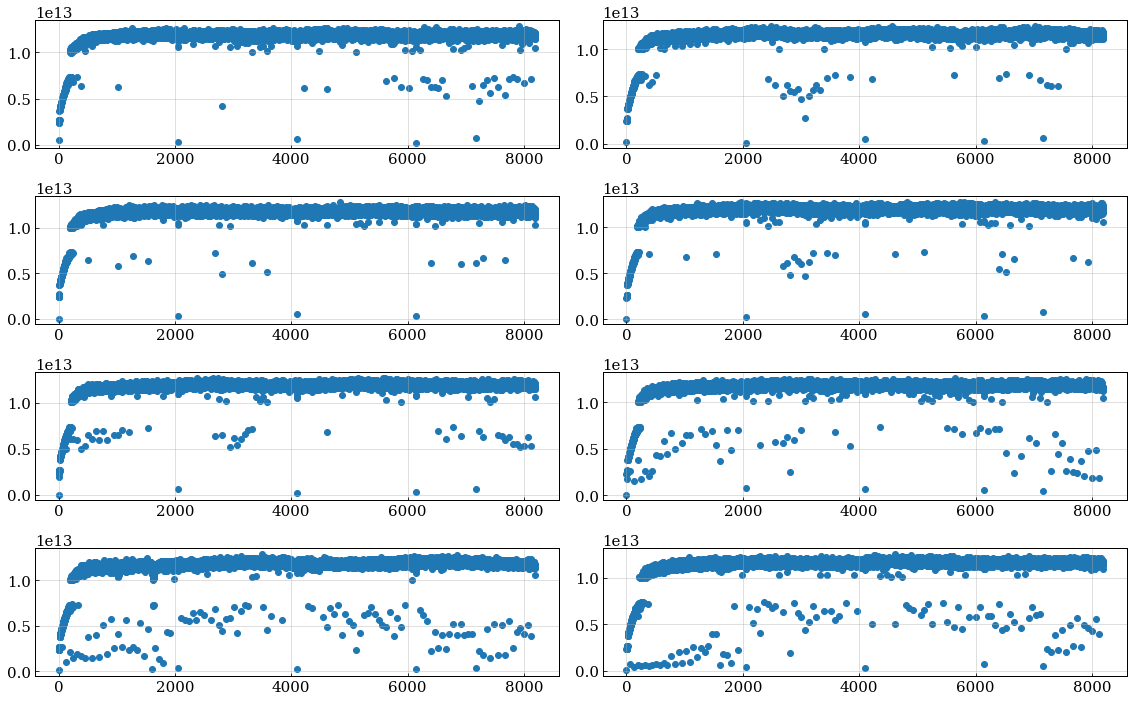

In [2]:
f = h5py.File("/Volumes/EXTRSSD/CRS_data/digital_gains/20260224T130143Z_pathfinder_corr8_digitalgain/gains.hdf5","r")

print(list(f.keys()))
print(f['gain_lin']) # total 8 adc channels and 8192 frequency bins 
#print(f['gain_lin'][1,7]) #adc channel 1 frequency bin 7
#print(f['gain_log'][1,7])
lin_gains=np.array(f['gain_lin'][:,:])
log_gains=np.array(f['gain_log'][:,:])
#print(log_gains)

plt.figure(figsize=[16,10])
print(f"\nCalculating digital gains of the channels...")
gains=lin_gains*np.exp(log_gains) # compute gains 
print(f"Gains shape: {gains.shape}")
print(f"Digital gains are:\n {gains}")

i = 0
for i in np.arange(0,8,1):  
    plt.subplot(4,2,i+1)
    #Digital gain of every channel
    plt.scatter(range(0,8192,1), gains[i,:]) # i referes to input channel (total 8 ch on csr corr)
    #plt.title( " %s " %(inputs[i]))
plt.tight_layout()

## Reading correlator file -- 

In [23]:
f = h5py.File("/Volumes/EXTRSSD/CRS_data/20260224T130143Z_pathfinder_corr8/0.hdf5","r")
print(list(f.keys()))
print(f['adc'])
print(f['counts'])
print(f['fft'])
print(f['index_map'][])
print(f['sat'])
print(f['stats'])
print(f['vis']) # 256 time indices, 8192 freq indices, 36 visibility products  

['adc', 'counts', 'fft', 'index_map', 'sat', 'stats', 'vis']
<HDF5 dataset "adc": shape (8, 10, 16384), type "<i2">
<HDF5 dataset "counts": shape (256,), type "<u4">
<HDF5 dataset "fft": shape (8, 10, 8192), type "<c16">
<HDF5 group "/index_map" (3 members)>
<HDF5 dataset "sat": shape (256, 8192, 36), type "<c8">
<HDF5 group "/stats" (8 members)>
<HDF5 dataset "vis": shape (256, 8192, 36), type "<c16">


In [32]:
print(f['index_map']['time'])
print(f['index_map']['freq'])
print(f['index_map']['prod'])

<HDF5 dataset "time": shape (256,), type "<f8">
<HDF5 dataset "freq": shape (8192,), type "<f8">
<HDF5 dataset "prod": shape (36, 2), type "<i2">


In [17]:
corr= f['vis'][:,:,0] 
print(f'corr data shape: {corr.shape}')
print(corr)

corr data shape: (256, 8192)
[[11464751.+0.j  7504309.+0.j  8370057.+0.j ... 11140733.+0.j
  11343358.+0.j 10607337.+0.j]
 [11723572.+0.j  5704132.+0.j  8396191.+0.j ... 11188154.+0.j
  11349926.+0.j 10746316.+0.j]
 [11935157.+0.j  5413384.+0.j 10475504.+0.j ... 11312813.+0.j
  11490266.+0.j 10906529.+0.j]
 ...
 [       0.+0.j        0.+0.j        0.+0.j ...        0.+0.j
         0.+0.j        0.+0.j]
 [       0.+0.j        0.+0.j        0.+0.j ...        0.+0.j
         0.+0.j        0.+0.j]
 [       0.+0.j        0.+0.j        0.+0.j ...        0.+0.j
         0.+0.j        0.+0.j]]


In [35]:
## Reading correlation files -- 
file_path = '/Volumes/EXTRSSD/CRS_data/20260224T130143Z_pathfinder_corr8/*' 
corr_data = read_corr_mode_h5(file_path, f_start=0, f_stop=1) 
pow_mag, pow_phase = get_mag_phase(corr_data.vis)
print("done getting pow_mag and pow_phase")
sat_data = corr_data.sat.real

corr_size=corr_data.vis[:,:,:].shape 
print('corr data shape: {}'.format(corr_size)) # time bins - freq bins - corr indices

Reading File: /Volumes/EXTRSSD/CRS_data/20260224T130143Z_pathfinder_corr8/0.hdf5
Appended vis data and time stream from /Volumes/EXTRSSD/CRS_data/20260224T130143Z_pathfinder_corr8/0.hdf5
Done!!!!!!!
done getting pow_mag and pow_phase
corr data shape: (256, 8192, 36)


In [ ]:
tmin,tmax=[0,corr_size[0]]
print(corr_data.vis.real.shape)
print(f"real power : {corr_data.vis.real[tmin:tmax,315,1]}")
print(f"imag power : {corr_data.vis.imag[tmin:tmax,315,1]}") 
print(f"abs power : {pow_mag[tmin:tmax,315,1]}")

total time bins (considered for the plots) are 256
lowest time bin 0 and highest time bin 256


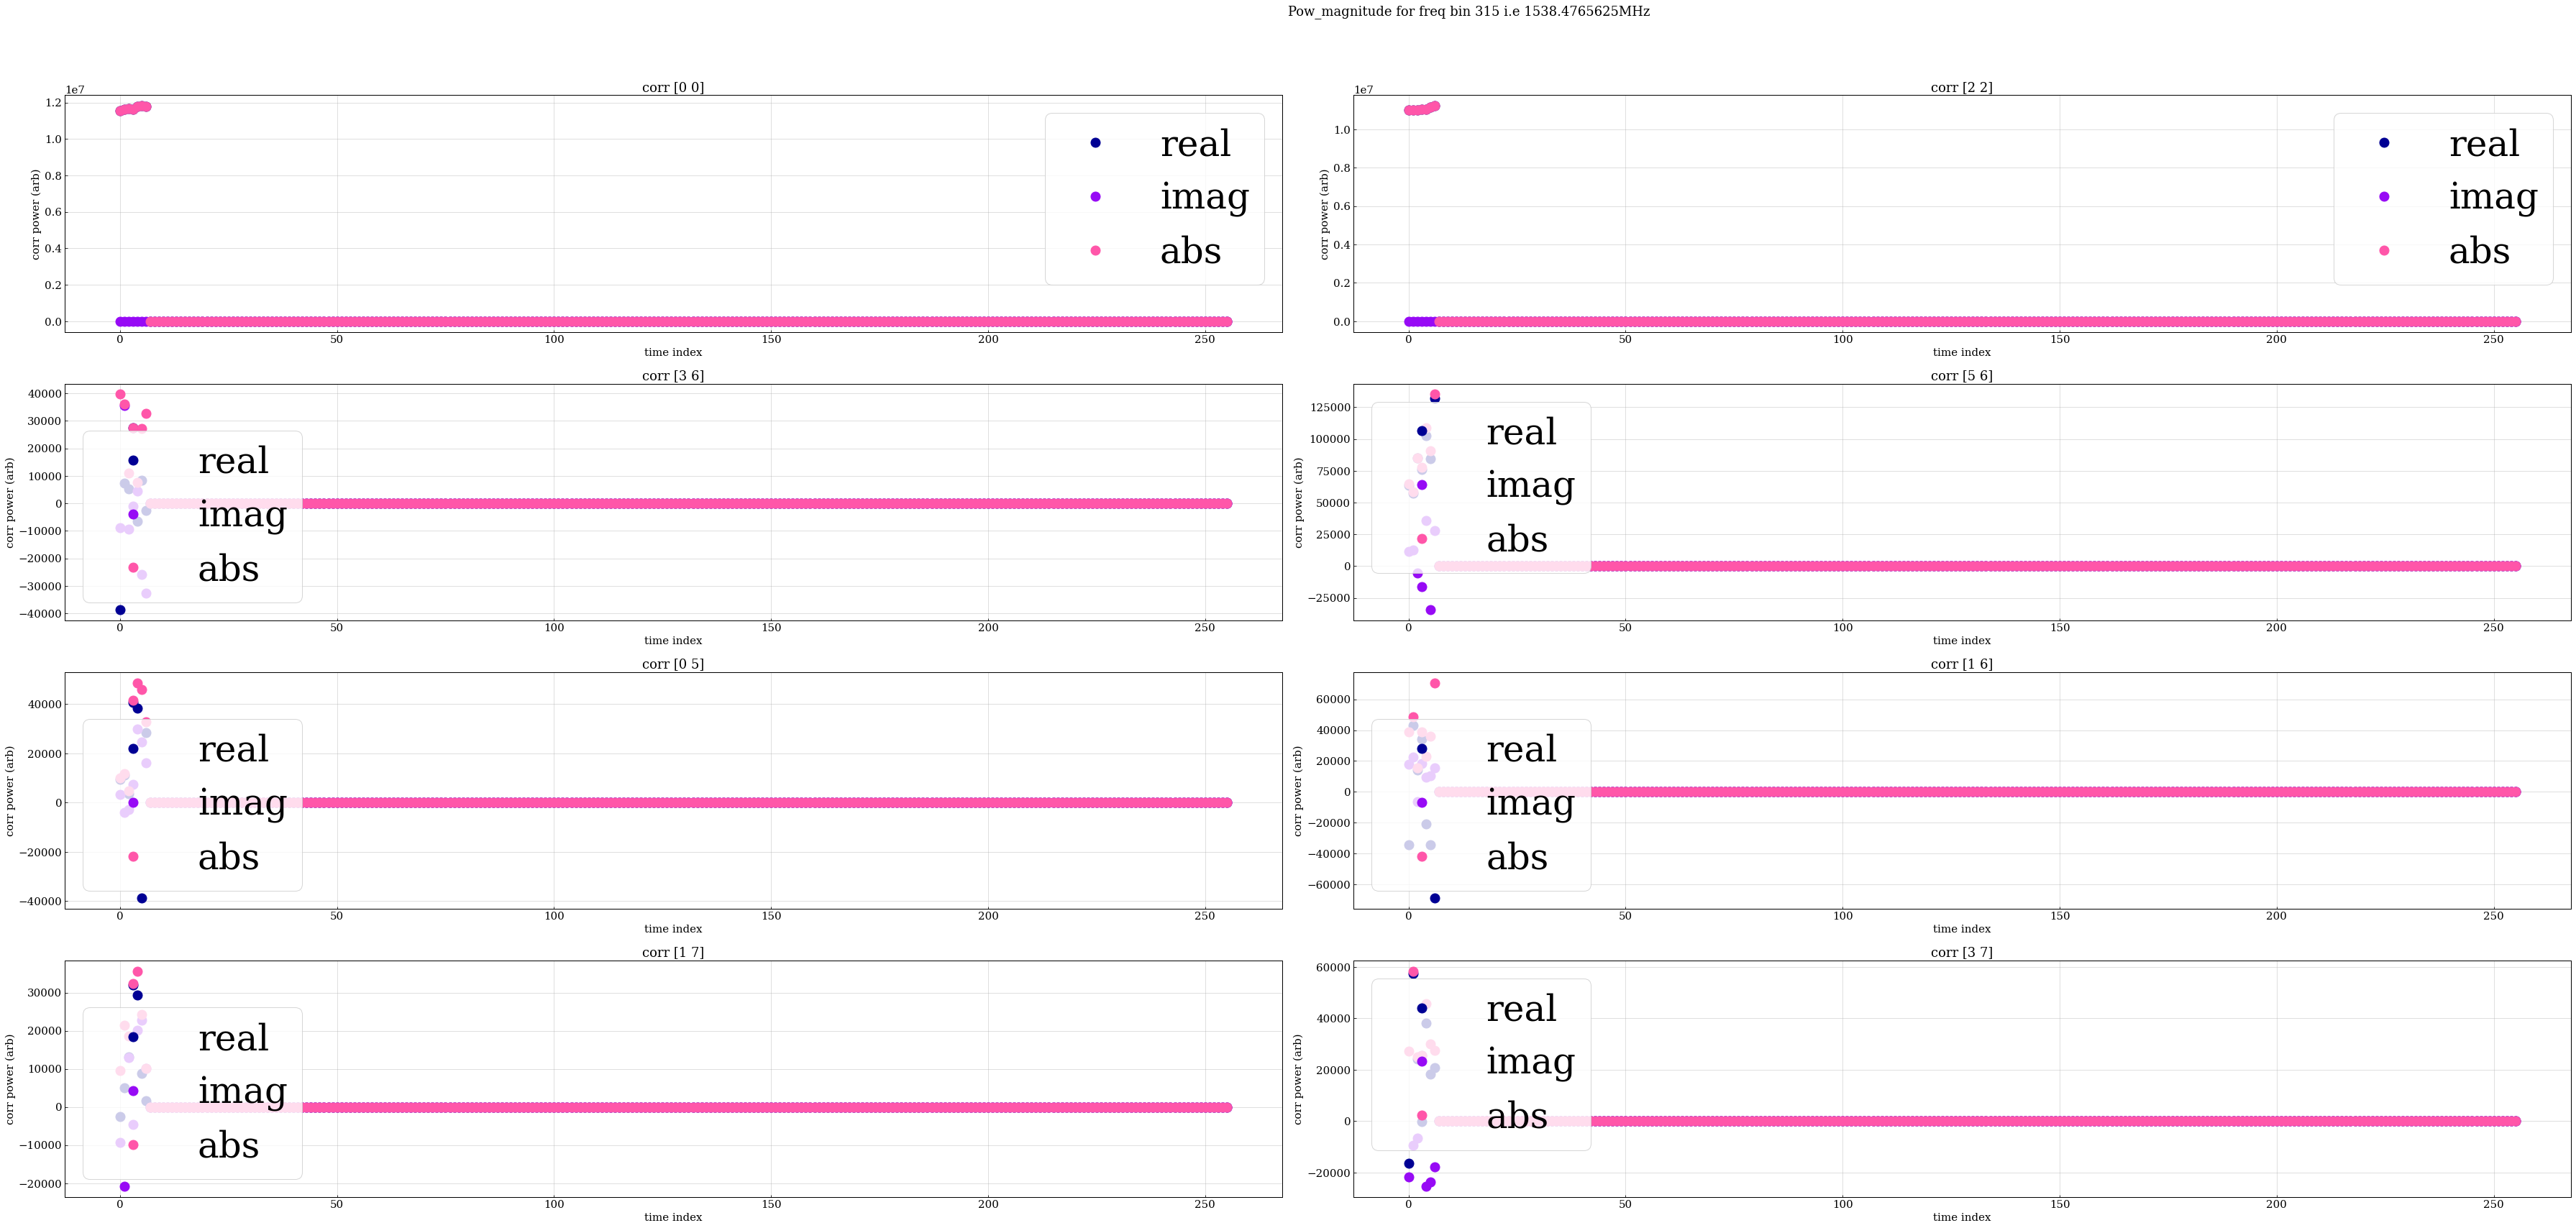

In [59]:
#Plotting real and imag correlation powers against time index for a given set of frequencies -- 
tmin,tmax=[0,corr_size[0]]
freq_arr=[315]
# autos indices -- 0,8,15,21,26,30,33,35 
corr_indices=[0,8,15,21,26,30,33,35]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=0+((8192-f_ind)*0.1953125)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(corr_data.vis.real[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[300], label='real')
        ax.plot(corr_data.vis.imag[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[900], label='imag')
        ax.plot(pow_mag[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[1200], label='abs')  
        ax.legend(fontsize=50)
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/real_imag_corr_powers_1ms_files61-65_DC_IQ_corrected_med.pdf")

#delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
#print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
#print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 